## Setup:
Setting up our mutual funds. Note that we have 4 mutual funds [A,B,C,D] with the following distributions/returns:

- A: $Unif[-40\%, 60\%]$
- B: $Unif[-10\%, 24\%]$
- C: $Normal(7\%, (2\%)^2)$
- D: $Unif[5\%, 7\%]$

We will also start with `$1,000,000`. Our goal will be to determine the best investment strategy.

The code below contains several functions about portfolios, which are an array of 4 numbers indicating the amount invested in each stock respectively.

In [85]:
# %pip install numpy matplotlib
# uncomment during first run to install dependencies

import numpy as np
import matplotlib.pyplot as plt

NUM_SIMS = 100000
SEED = 0
SHORT_TERM_YEARS = 3
LONG_TERM_YEARS = 10
RETIREMENT_YEARS = 50

np.random.seed(SEED)

def setup_portfolios(starting_portfolio: list[float], num_portfolios: int) -> list[list[float]]:
        return [starting_portfolio.copy() for _ in range(num_portfolios)]

# Returns a portfolio containing the mean value of each stock across all portfolios
def get_mean_portfolio(portfolios: list[list[float]]) -> np.ndarray:
        return np.mean(portfolios, axis=0)

# Returns an array of the values of a specific stock type across all portfolios
def filter_portfolios(portfolios: list[list[float]], stock_type: str) -> np.ndarray:
        
        np_arr = np.array(portfolios)

        match stock_type:
                case 'A':
                        return np_arr[:, 0]
                case 'B':
                        return np_arr[:, 1]
                case 'C':
                        return np_arr[:, 2]
                case 'D':
                        return np_arr[:, 3]
                case _:
                        raise ValueError(f"Invalid stock type: {stock_type}")

# Returns an array containing the total value of each portfolio
def get_portfolio_totals(portfolios: list[list[float]]) -> np.ndarray:
        return np.sum(portfolios, axis=1)

# Returns the number of values that have a total value greater than the threshold
def percent_of_values_above(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values > threshold) / len(values) * 100

# Returns the number of values that have a total value less than or equal to the threshold
def percent_of_values_below(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values <= threshold) / len(values) * 100

def percent_of_return(end, start) -> float:
        return (end - start) / start * 100

def percent_of_outliers(values: np.ndarray) -> float:
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr = q75 - q25
        lower_bound = q25 - 1.5 * iqr
        upper_bound = q75 + 1.5 * iqr
        outliers = np.sum((values < lower_bound) | (values > upper_bound))
        return outliers / len(values) * 100

def print_stats(values: np.ndarray, header: str = "Stats:", footer: str = ""):
        mean = np.mean(values)
        median = np.median(values)
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr_value = q75 - q25
        outlier_percentage = percent_of_outliers(values)
        std = np.std(values)

        print(
                f"{header}\n"
                f"Mean: ${mean:,.2f}\n"
                f"Mean return: {percent_of_return(mean, 1000000):.2f}%\n"
                f"Standard Deviation: ${std:,.2f}\n\n"
                
                f"Median: ${median:,.2f}\n"
                f"Median return: {percent_of_return(median, 1000000):.2f}%\n"
                f"Min: ${np.min(values):,.2f}\n"
                f"Max: ${np.max(values):,.2f}\n"
                f"Q1 (25th percentile): ${q25:,.2f}\n"
                f"Q3 (75th percentile): ${q75:,.2f}\n"
                f"IQR: ${iqr_value:,.2f}\n\n"

                f"Percentage of failed portfolios: {percent_of_values_below(values, 1000000):.2f}%\n"
                f"Percentage of outliers: {outlier_percentage:.2f}%\n\n"

                f"Risk-averse score: {(0.7 * q25 + 0.2 * median + 0.1 * q75) // 1000:.0f}\n"
                f"Risk-neutral score: {(0.1 * q25 + 0.8 * median + 0.1 * q75) // 1000:.0f}\n"
                f"Risk-seeking score: {(0.1 * q25 + 0.2 * median + 0.7 * q75) // 1000:.0f}\n"
                f"{footer}"
        )

# Simulates one year of returns for a single portfolio
def simulate_once(portfolio: list[float]):
        change_a = np.random.uniform(-0.4, 0.6)
        change_b = np.random.uniform(-0.1, 0.24)
        change_c = np.random.normal(0.07, 0.02)
        change_d = np.random.uniform(0.05, 0.07)

        portfolio[0] *= (1 + change_a)
        portfolio[1] *= (1 + change_b)
        portfolio[2] *= (1 + change_c)
        portfolio[3] *= (1 + change_d)

# Simulates multiple years of returns for a list of portfolios
def simulate_multiple(portfolios: list[list[float]], num_years: int):
        for _ in range(num_years):
                for portfolio in portfolios:
                        simulate_once(portfolio)

### Question 1:

##### What is the expected return if you invest option A for 3 years? 

In [86]:
PORTFOLIO = [1000000.0, 1000000.0, 1000000.0, 1000000.0]  # $1,000,000 in asset A, $0 in B, C, D

portfolios = setup_portfolios(PORTFOLIO, NUM_SIMS)

simulate_multiple(portfolios, SHORT_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
print_stats(fund_A_values, header="+ Fund A stats after 3 years:")

+ Fund A stats after 3 years:
Mean: $1,332,978.55
Mean return: 33.30%
Standard Deviation: $628,224.01

Median: $1,215,037.73
Median return: 21.50%
Min: $232,680.14
Max: $4,032,441.91
Q1 (25th percentile): $858,540.94
Q3 (75th percentile): $1,689,778.17
IQR: $831,237.23

Percentage of failed portfolios: 35.17%
Percentage of outliers: 1.99%

Risk-averse score: 1012
Risk-neutral score: 1226
Risk-seeking score: 1511



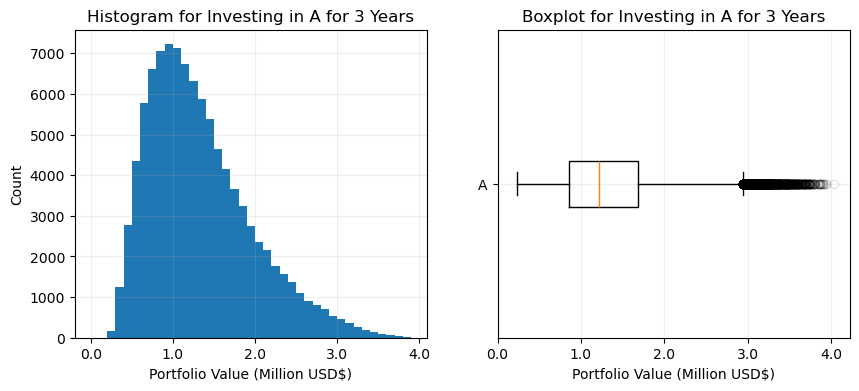

In [87]:
# plots for fund A

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_A_values, bins=range(0, 4000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in A for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 4.01, 1)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in A for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 4.01, 1)))
ax2.set_yticklabels(["A"])

plt.show()

##### What is the probability that your profit is more than 25%? 

$ P(T > 1,250,000) =  ? $

In [88]:
print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_A_values, 1250000):.2f}%")

Percentage of portfolios with over $1,250,000 after 3 years: 47.73%


##### What is the probability that you lose 25% of your money?

$ P(T \le 750,000) = ?$

In [89]:
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_A_values, 750000):.2f}%")

Percentage of portfolios with $750,000 or less after 3 years: 17.59%


### Question 2:
##### What are your answers if you invest in fund B or C? And what is your recommendation for the best option?

In [90]:
# calculations for fund B
fund_B_values = filter_portfolios(portfolios, "B")
print_stats(fund_B_values, header="+ Fund B stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_B_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_B_values, 750000):.2f}%")

+ Fund B stats after 3 years:
Mean: $1,225,102.33
Mean return: 22.51%
Standard Deviation: $195,195.23

Median: $1,211,819.07
Median return: 21.18%
Min: $741,571.19
Max: $1,886,874.72
Q1 (25th percentile): $1,081,580.09
Q3 (75th percentile): $1,355,228.16
IQR: $273,648.07

Percentage of failed portfolios: 12.16%
Percentage of outliers: 0.32%

Risk-averse score: 1134
Risk-neutral score: 1213
Risk-seeking score: 1299

Percentage of portfolios with over $1,250,000 after 3 years: 42.71%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


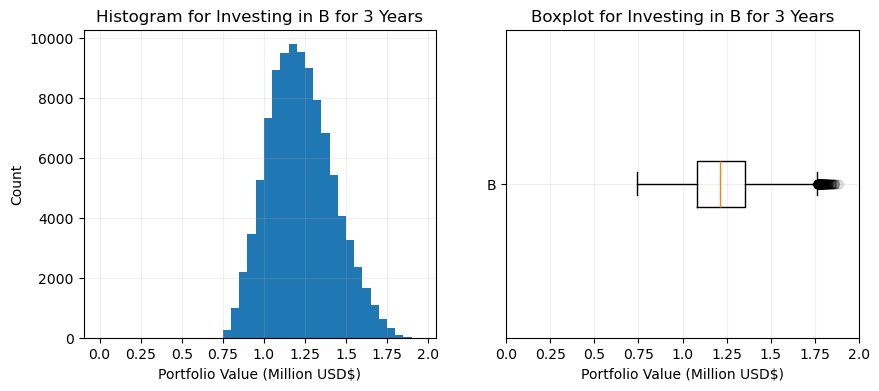

In [91]:
# plots for fund B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_B_values, bins=range(0, 2000000, 50000)) # each bin will be 50k
ax1.set_xticks(ticks=range(0,2000000,200000))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in B for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 2000001, 250000), labels=list(np.arange(0, 2.01, 0.25)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in B for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 2000001, 250000), labels=list(np.arange(0, 2.01, 0.25)))
ax2.set_yticklabels(["B"])

plt.show()


In [92]:
# calculations for fund C
fund_C_values = filter_portfolios(portfolios, "C")
print_stats(fund_C_values, header="+ Fund C stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_C_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_C_values, 750000):.2f}%")


+ Fund C stats after 3 years:
Mean: $1,225,044.17
Mean return: 22.50%
Standard Deviation: $39,682.91

Median: $1,224,593.25
Median return: 22.46%
Min: $1,052,171.33
Max: $1,402,065.01
Q1 (25th percentile): $1,197,999.20
Q3 (75th percentile): $1,251,745.71
IQR: $53,746.51

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.63%

Risk-averse score: 1208
Risk-neutral score: 1224
Risk-seeking score: 1240

Percentage of portfolios with over $1,250,000 after 3 years: 26.40%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


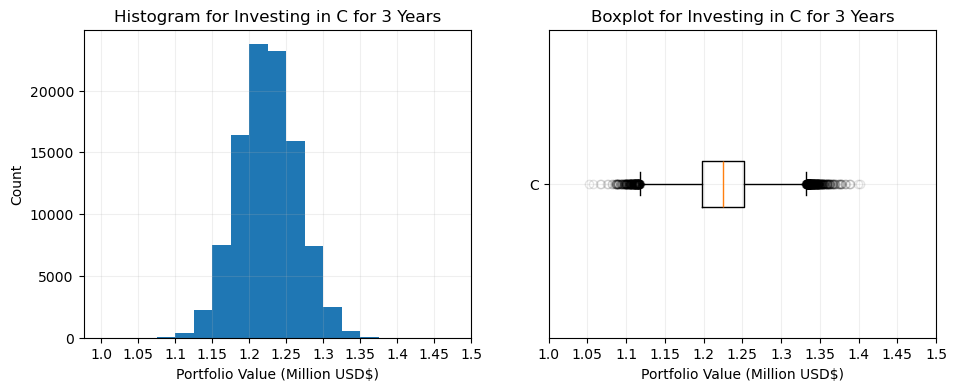

In [93]:
# plots for fund C

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

histogram = ax1.hist(fund_C_values, bins=range(1000000, 1500000, 25000)) # each bin will be 25k
ax1.set_xticks(ticks=range(1000000,1500000,50000))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 1500001, 50000), labels=list(np.round(np.arange(1, 1.51, 0.05), 3)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 1500001, 50000), labels=list(np.round(np.arange(1, 1.51, 0.05), 3)))
ax2.set_yticklabels(["C"])

plt.show()


##### What about investing everything in fund D for 3 years?

In [94]:
# calculations for fund D
fund_D_values = filter_portfolios(portfolios, "D")
print_stats(fund_D_values, header="+ Fund D stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_D_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_D_values, 750000):.2f}%")

+ Fund D stats after 3 years:
Mean: $1,191,083.07
Mean return: 19.11%
Standard Deviation: $11,251.28

Median: $1,191,020.76
Median return: 19.10%
Min: $1,158,370.78
Max: $1,224,486.87
Q1 (25th percentile): $1,183,089.18
Q3 (75th percentile): $1,199,041.38
IQR: $15,952.20

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.02%

Risk-averse score: 1186
Risk-neutral score: 1191
Risk-seeking score: 1195

Percentage of portfolios with over $1,250,000 after 3 years: 0.00%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


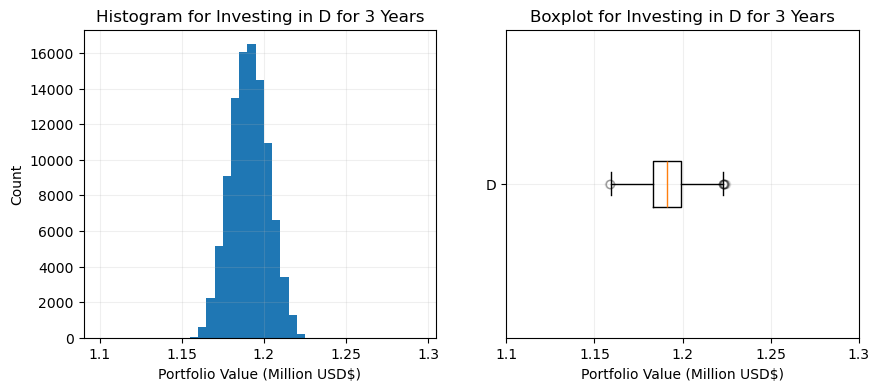

In [95]:
# plots for fund D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_D_values, bins=range(1100000, 1300000, 5000)) # each bin will be 5k
ax1.set_xticks(ticks=range(1100000,1300001,50000), labels=list(np.round((np.arange(1.1, 1.31, 0.05)), decimals=2)))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(ticks=range(1100000,1300001,50000), labels=list(np.round((np.arange(1.1, 1.31, 0.05)), decimals=2)))
ax2.set_yticklabels(["D"])

plt.show()


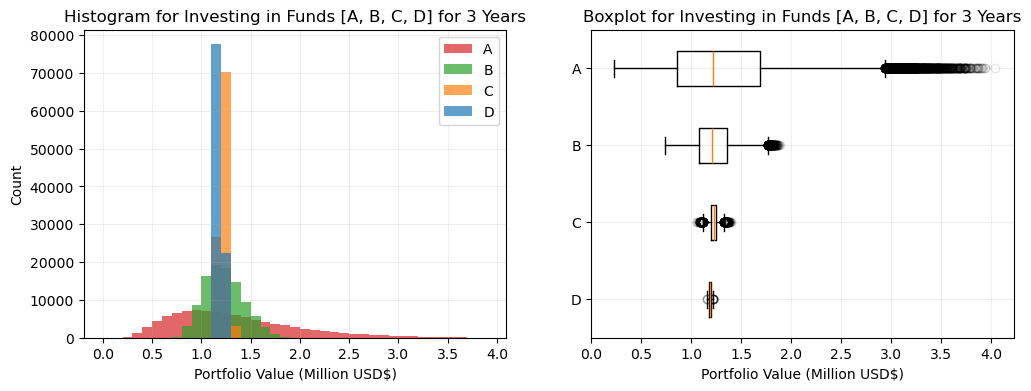

In [96]:
# combining outcomes for funds A, B, C, D into into a single plot for simplicity

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

stacked_hist = ax1.hist([fund_D_values, fund_C_values, fund_B_values, fund_A_values], histtype="stepfilled", bins=range(0, 4000000, 100000), label=["D", "C", "B", "A"], alpha=0.7)
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in Funds [A, B, C, D] for 3 Years")
ax1.legend()
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 500000), labels=list(np.arange(0, 4.01, 0.5)))
ax1.set_ylabel("Count")

multi_boxplot = ax2.boxplot([fund_D_values, fund_C_values, fund_B_values, fund_A_values], label=["D", "C", "B", "A"], vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in Funds [A, B, C, D] for 3 Years")
ax2.set_xticks(range(0, 4000001, 500000), labels=list(np.arange(0, 4.01, 0.5)))
ax2.set_yticks(ticks=[1,2,3,4], labels=["D", "C", "B", "A"])
ax2.set_xlabel("Portfolio Value (Million USD$)")
plt.show()

### Question 3:
##### How will your answer/recommendation change if you are planning for 10 years, instead of 3 years?

In [97]:
portfolios = setup_portfolios([1000000.0, 1000000.0, 1000000.0, 1000000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
fund_B_values = filter_portfolios(portfolios, "B")
fund_C_values = filter_portfolios(portfolios, "C")
fund_D_values = filter_portfolios(portfolios, "D")

Here are some statistics about the funds:

In [98]:
print_stats(fund_A_values, "+ Fund A stats after 10 years:")
print_stats(fund_B_values, "+ Fund B stats after 10 years:")
print_stats(fund_C_values, "+ Fund C stats after 10 years:")
print_stats(fund_D_values, "+ Fund D stats after 10 years:")

+ Fund A stats after 10 years:
Mean: $2,588,001.37
Mean return: 158.80%
Standard Deviation: $2,491,665.52

Median: $1,823,984.31
Median return: 82.40%
Min: $48,099.65
Max: $36,668,648.54
Q1 (25th percentile): $1,001,964.89
Q3 (75th percentile): $3,284,835.49
IQR: $2,282,870.61

Percentage of failed portfolios: 24.92%
Percentage of outliers: 6.28%

Risk-averse score: 1394
Risk-neutral score: 1887
Risk-seeking score: 2764

+ Fund B stats after 10 years:
Mean: $1,964,207.71
Mean return: 96.42%
Standard Deviation: $577,245.60

Median: $1,888,561.51
Median return: 88.86%
Min: $486,470.36
Max: $5,609,621.65
Q1 (25th percentile): $1,546,283.13
Q3 (75th percentile): $2,300,943.13
IQR: $754,660.00

Percentage of failed portfolios: 1.59%
Percentage of outliers: 1.71%

Risk-averse score: 1690
Risk-neutral score: 1895
Risk-seeking score: 2143

+ Fund C stats after 10 years:
Mean: $1,966,873.81
Mean return: 96.69%
Standard Deviation: $116,125.12

Median: $1,963,680.60
Median return: 96.37%
Min: $1,

Here are the plots:

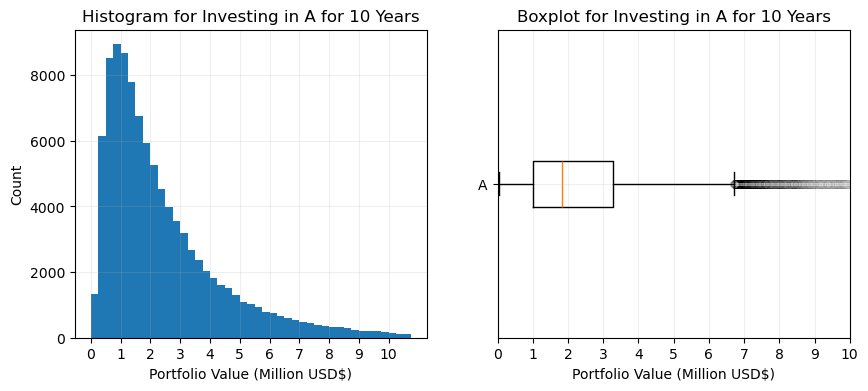

In [100]:
# fund A

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_A_values, bins=range(0, 11000000, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in A for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0,11000000, 1000000), list(range(0,11))) # type: ignore
ax1.set_ylabel("Count")


box_plot = ax2.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.005})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in A for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 11000000, 1000000), list(range(0,11))) # type: ignore
ax2.set_yticks([1], ["A"])
ax2.set_xlim(0,10000000)

plt.show()

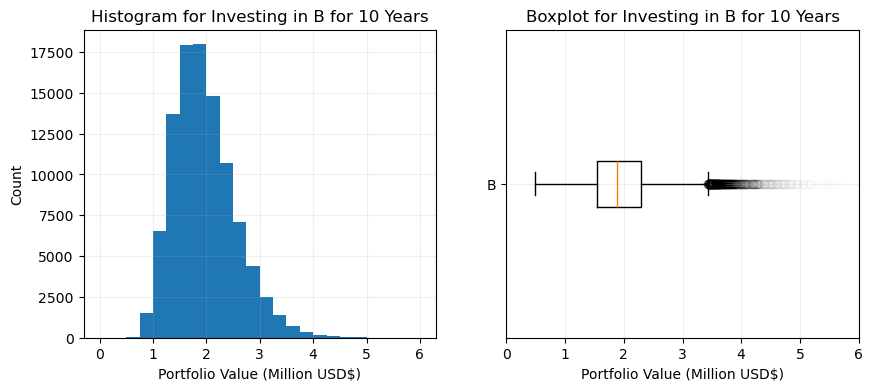

In [16]:
# fund B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_B_values, bins=range(0, 6000001, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in B for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0,6000001, 1000000), list(range(0,7))) # type: ignore
ax1.set_ylabel("Count")


box_plot = ax2.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in B for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 6000001, 1000000), list(range(0,7))) # type: ignore
ax2.set_yticks([1], ["B"])
ax2.set_xlim(0,6000001) 

plt.show()

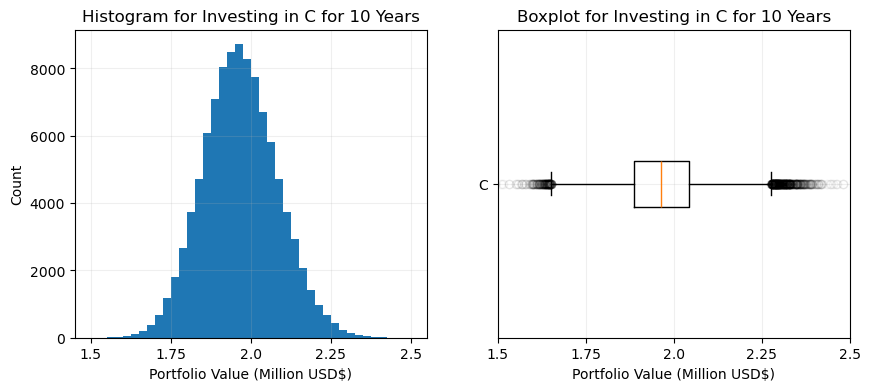

In [17]:
# fund C

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_C_values, bins=range(1500000, 2500001, 25000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1500000,2500001, 250000), list(np.arange(1.5, 2.6, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.05})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1500000, 2500001, 250000), list(np.arange(1.5, 2.6, 0.25))) # type: ignore
ax2.set_yticks([1], ["C"])
ax2.set_xlim(1500000,2500001)

plt.show()

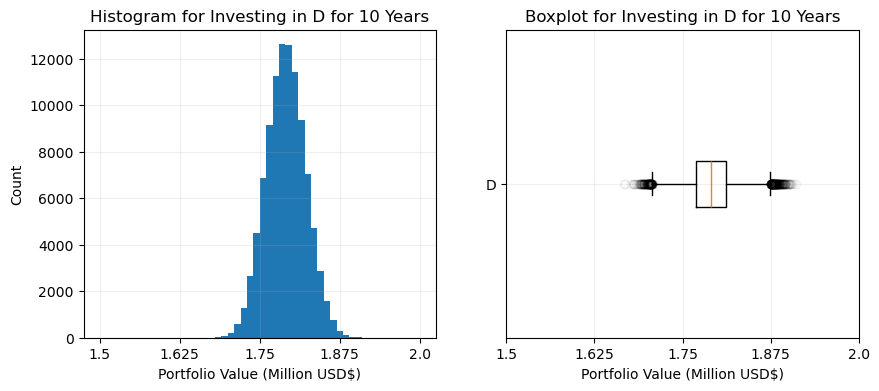

In [18]:
# fund D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_D_values, bins=range(1500000, 2000001, 10000)) # each bin will be 10k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1500000, 2000001, 125000), list(np.arange(1.5, 2.01, 0.125))) # type: ignore
ax1.set_ylabel("Count")
	
box_plot = ax2.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.05})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1500000, 2000001, 125000), list(np.arange(1.5, 2.01, 0.125))) # type: ignore
ax2.set_yticks([1], ["D"])
ax2.set_xlim(1500000,2000001)

plt.show()

### Question 4:

##### Will it be a better strategy if we invest `$500,000` in fund A and `$500,000` in fund D? 

First, let's start with simulating 3 years:

In [102]:
portfolios = setup_portfolios([500000.0, 0, 0, 500000.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $1,262,295.17
Mean return: 26.23%
Standard Deviation: $314,042.74

Median: $1,203,285.11
Median return: 20.33%
Min: $703,247.41
Max: $2,557,511.72
Q1 (25th percentile): $1,024,907.57
Q3 (75th percentile): $1,439,777.73
IQR: $414,870.16

Percentage of failed portfolios: 21.50%
Percentage of outliers: 2.00%

Risk-averse score: 1102
Risk-neutral score: 1209
Risk-seeking score: 1350



Graphs for 3 year simulation:

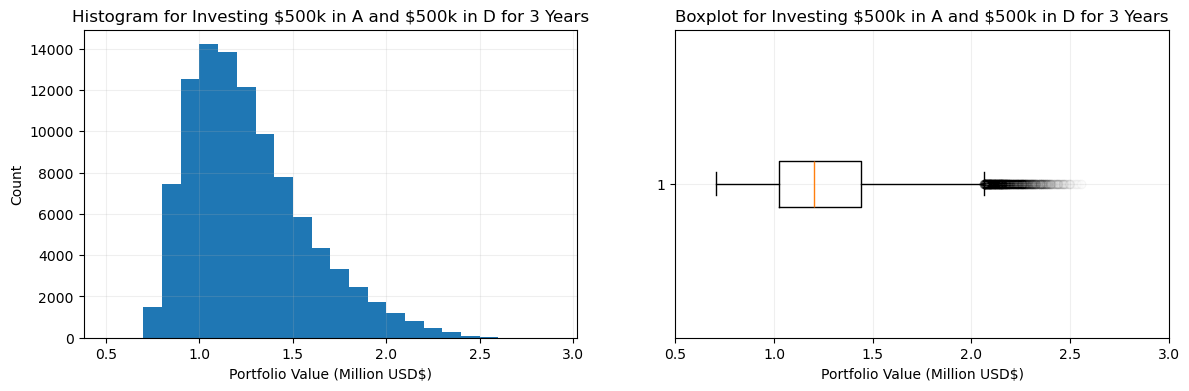

In [103]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(500000, 3000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A and \$500k in D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(500000,3000001, 500000), labels=list(np.arange(0.5, 3.01, 0.5)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A and \$500k in D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(500000,3000001, 500000), labels=list(np.arange(0.5, 3.01, 0.5)))

plt.show()

Now let's simulate for 10 years:

In [21]:
portfolios = setup_portfolios([500000.0, 0, 0, 500000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $2,190,769.19
Mean return: 119.08%
Standard Deviation: $1,266,816.34

Median: $1,810,101.95
Median return: 81.01%
Min: $898,369.77
Max: $23,458,054.43
Q1 (25th percentile): $1,393,907.35
Q3 (75th percentile): $2,535,945.78
IQR: $1,142,038.43

Percentage of failed portfolios: 0.78%
Percentage of outliers: 6.27%

Risk-averse score: 1591
Risk-neutral score: 1841
Risk-seeking score: 2276



Graphs for 10 year simulation:

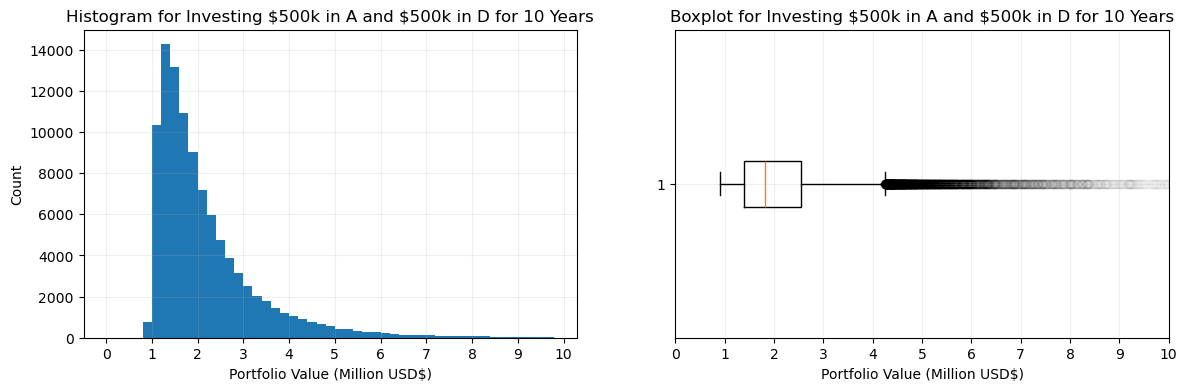

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 10000000, 200000)) # each bin will be 200k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A and \$500k in D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 10000001, 1000000), list(range(0, 11))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A and \$500k in D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0,10000001, 1000000), list(range(0, 11))) # type: ignore
ax2.set_xlim(0, 10000000)

plt.show()

##### Or how about `$600,000` in fund B and `$400,000` in fund C?

We again start by simulating 3 years:

In [104]:
portfolios = setup_portfolios([0, 600000.0, 400000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $1,224,621.55
Mean return: 22.46%
Standard Deviation: $118,009.25

Median: $1,216,626.04
Median return: 21.66%
Min: $910,120.89
Max: $1,645,700.84
Q1 (25th percentile): $1,138,178.02
Q3 (75th percentile): $1,302,512.59
IQR: $164,334.57

Percentage of failed portfolios: 1.36%
Percentage of outliers: 0.36%

Risk-averse score: 1170
Risk-neutral score: 1217
Risk-seeking score: 1268



Graphs for 3 year simulation:

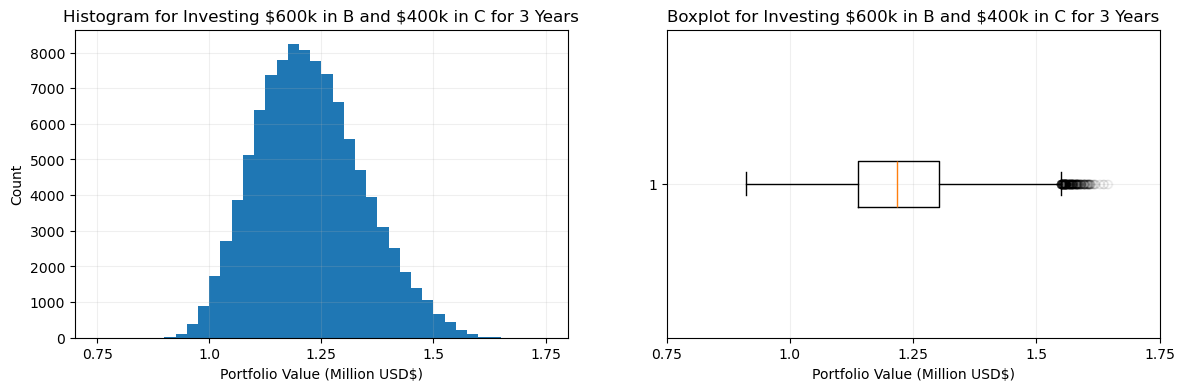

In [107]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 1750001, 25000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$600k in B and \$400k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 1750001, 250000), labels=list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.05})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$600k in B and \$400k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 1750001, 250000), labels=list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax2.set_xlim(750000, 1750001)

plt.show()

Now to simulate for 10 years:

In [25]:
portfolios = setup_portfolios([0, 600000.0, 400000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $1,964,527.61
Mean return: 96.45%
Standard Deviation: $354,702.57

Median: $1,915,954.34
Median return: 91.60%
Min: $1,078,865.52
Max: $4,386,353.37
Q1 (25th percentile): $1,708,124.66
Q3 (75th percentile): $2,170,451.61
IQR: $462,326.95

Percentage of failed portfolios: 0.00%
Percentage of outliers: 1.81%

Risk-averse score: 1795
Risk-neutral score: 1920
Risk-seeking score: 2073



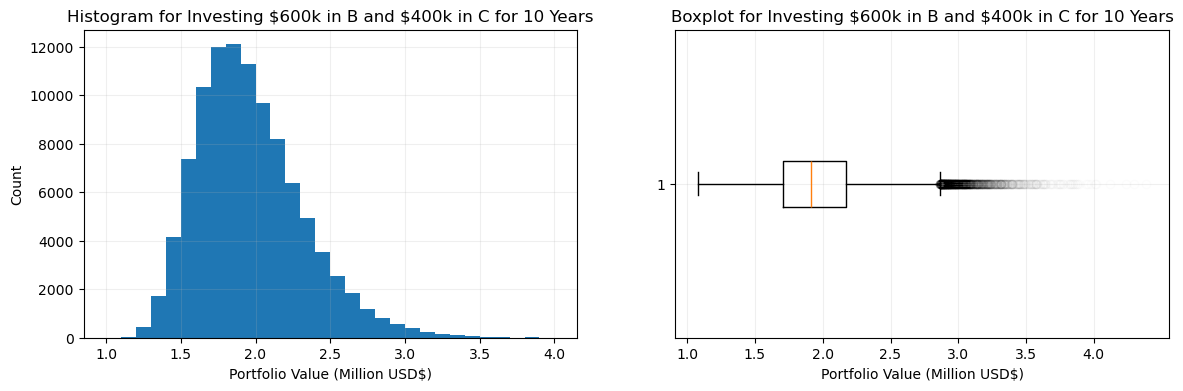

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(1000000, 4000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$600k in B and \$400k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 4000001, 500000), list(np.arange(1, 4.1, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$600k in B and \$400k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 4000001, 500000), list(np.arange(1, 4.1, 0.5))) # type: ignore
plt.show()

##### Will it be a better strategy if we invest `$500,000` in fund A, `$300,000` in fund B and `$200,000` in fund C?

We start with simulating for 3 years:

In [27]:
portfolios = setup_portfolios([500000.0, 300000.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $1,279,034.82
Mean return: 27.90%
Standard Deviation: $320,412.81

Median: $1,219,966.96
Median return: 22.00%
Min: $611,607.59
Max: $2,699,314.23
Q1 (25th percentile): $1,039,938.49
Q3 (75th percentile): $1,461,583.27
IQR: $421,644.78

Percentage of failed portfolios: 19.61%
Percentage of outliers: 1.97%

Risk-averse score: 1118
Risk-neutral score: 1226
Risk-seeking score: 1371



Graphs for 3 years:

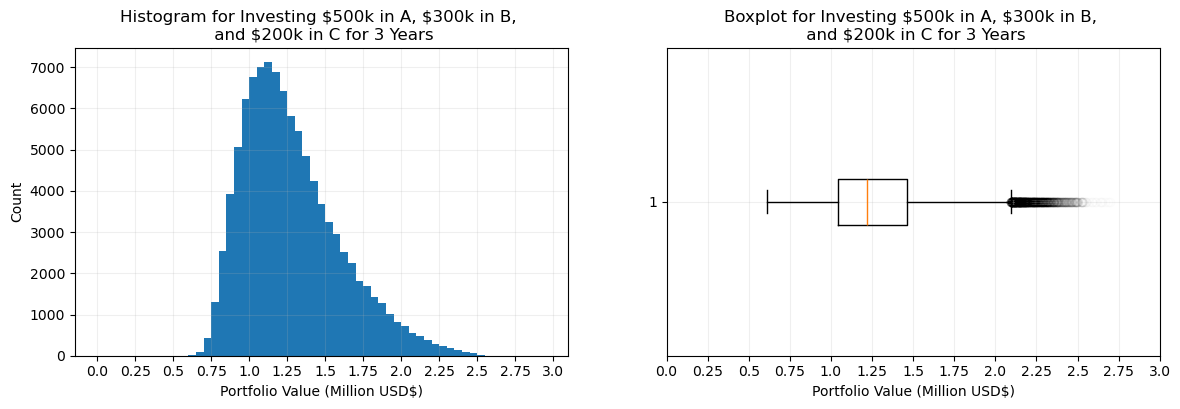

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 3000000, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 3000001, 250000), list(np.arange(0, 3.1, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 3000001, 250000), list(np.arange(0, 3.1, 0.25))) # type: ignore

plt.show()

Now we simulate for 10 years:

In [29]:
portfolios = setup_portfolios([500000.0, 300000.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $2,281,942.42
Mean return: 128.19%
Standard Deviation: $1,280,849.63

Median: $1,908,721.62
Median return: 90.87%
Min: $651,813.97
Max: $28,213,755.92
Q1 (25th percentile): $1,481,883.54
Q3 (75th percentile): $2,645,275.38
IQR: $1,163,391.83

Percentage of failed portfolios: 1.60%
Percentage of outliers: 6.21%

Risk-averse score: 1683
Risk-neutral score: 1939
Risk-seeking score: 2381



Graphs for 10 year simulation:

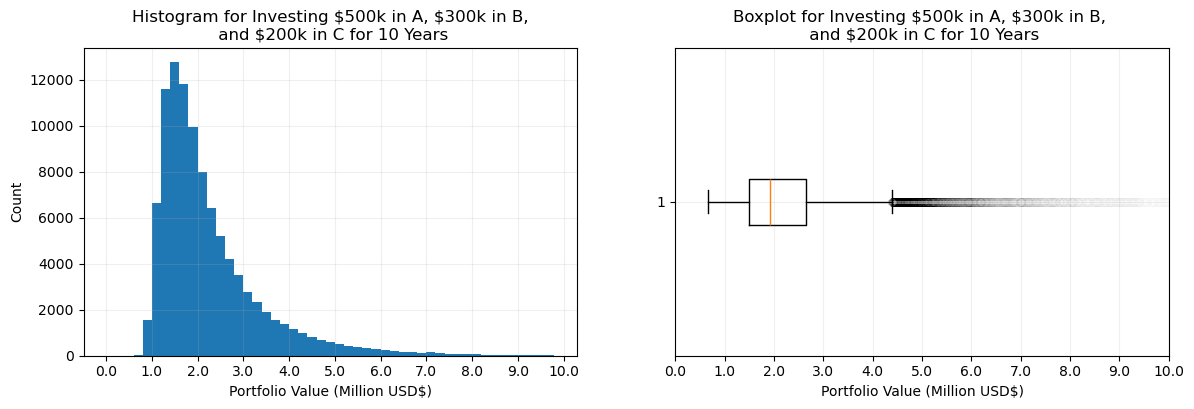

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(0, 10000000, 200000)) # each bin will be 200k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A, \$300k in B," + "\n " \
r"and \$200k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 10000001, 1000000), list(np.arange(0, 10.1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.005})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(0, 10000000)
ax2.set_xticks(range(0, 10000001, 1000000), list(np.arange(0, 10.1))) # type: ignore

plt.show()

##### How about investing `$250,000` in each fund?

We start with simulating for 3 years:

In [31]:
portfolios = setup_portfolios([250000.0, 250000.0, 250000.0, 250000.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $1,243,038.97
Mean return: 24.30%
Standard Deviation: $164,759.31

Median: $1,216,250.65
Median return: 21.63%
Min: $879,846.35
Max: $1,990,252.31
Q1 (25th percentile): $1,121,436.36
Q3 (75th percentile): $1,338,351.17
IQR: $216,914.80

Percentage of failed portfolios: 2.98%
Percentage of outliers: 1.76%

Risk-averse score: 1162
Risk-neutral score: 1218
Risk-seeking score: 1292



Graphs for 3 years:

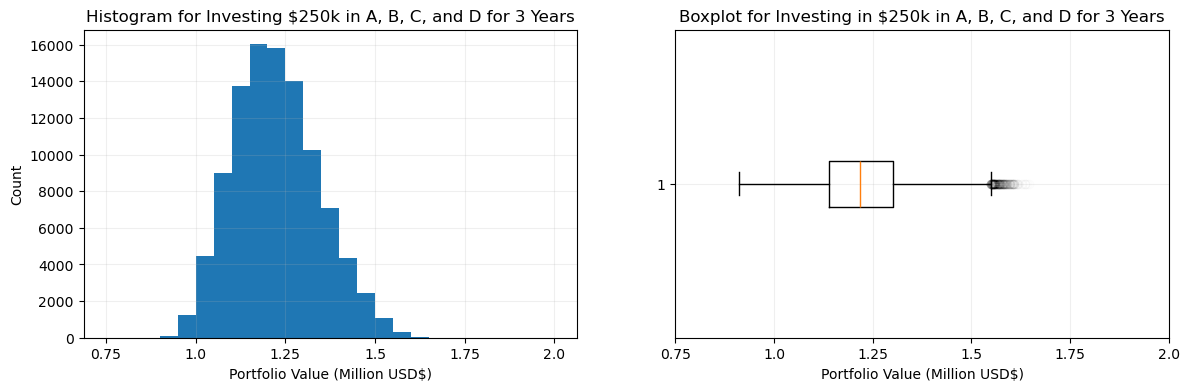

In [108]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 2000001, 50000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$250k in A, B, C, and D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 2000001, 250000), list(np.arange(0.75, 2.001, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$250k in A, B, C, and D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 2000001, 250000), list(np.arange(0.75, 2.01, 0.25))) # type: ignore
ax2.set_xlim(750000, 2000001)

plt.show()

Now we simulate for 10 years:

In [110]:
portfolios = setup_portfolios([250000.0, 250000.0, 250000.0, 250000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

print_stats(portfolio_totals)

Stats:
Mean: $2,080,683.37
Mean return: 108.07%
Standard Deviation: $654,790.89

Median: $1,906,014.61
Median return: 90.60%
Min: $1,158,685.73
Max: $14,269,444.82
Q1 (25th percentile): $1,672,277.12
Q3 (75th percentile): $2,276,468.48
IQR: $604,191.35

Percentage of failed portfolios: 0.00%
Percentage of outliers: 5.90%

Risk-averse score: 1779
Risk-neutral score: 1919
Risk-seeking score: 2141



Graphs for 10 years:

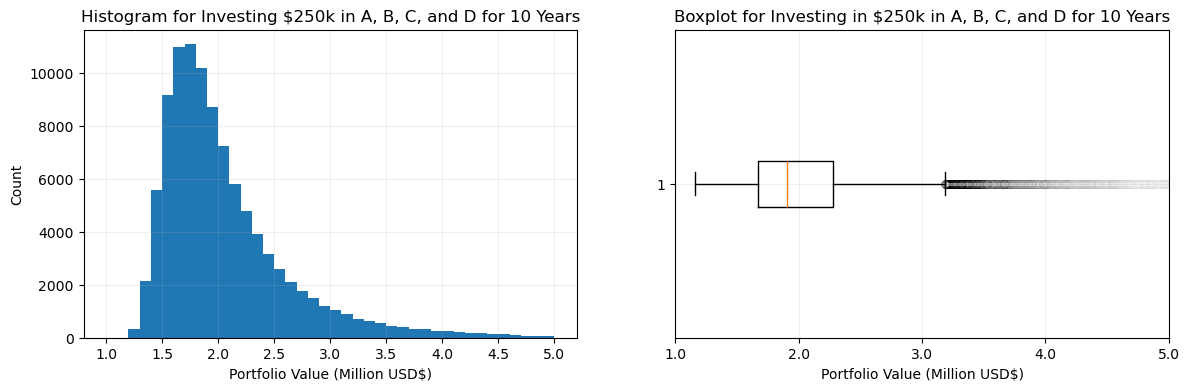

In [111]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(1000000, 5000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$250k in A, B, C, and D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 5000001, 500000), list(np.arange(1, 5.01, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.005})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$250k in A, B, C, and D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(1000000, 5000000)
ax2.set_xticks(range(1000000, 5000001, 1000000), list(np.arange(1, 5.1, 1))) # type: ignore

plt.show()

### Question 5:

##### What is the best strategy you would recommend?

markdown block: ***will put answer here !!!***